# Prepare Reference Projections
Manually process those

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import socket as socket
import os as os
import sys as sys
import multiprocessing as mp

socket_name = socket.gethostname()
    
if socket_name.startswith("bionc") or socket_name.startswith("hpc"):
    print("Leipzig Cluster detected!")
    path = "/mnt/archgen/users/hringbauer/git/projectPCA/"   
    #path = "/mnt/archgen/users/hringbauer/"
else: 
    raise RuntimeWarning("Not compatible machine. Check!!")
     
os.chdir(path)  # Set the right Path (in line with Atom default)
print(os.getcwd())
print(f"CPU Count: {mp.cpu_count()}")
print(sys.version_info)

#from projectPCA.eigenstrat_funcs import load_genos_autoeager, update_values
from projectPCA.run import project_eigenstrat, project_es_obj
from projectPCA.loadEigenstrat import get_eigenstrat_object

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

Leipzig Cluster detected!
/mnt/archgen/users/hringbauer/git/projectPCA
CPU Count: 128
sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)


### 0) Helper Functions

In [4]:
def create_subset_colors(df, ls=[], cs=[], savepath="", delete_substrings=[]):
    """Subset PCA dataframe and color_code"""
    dfs_new = []
    
    for l,c in zip (ls, cs):
        dft = df[df["pop"].str.contains(l)].copy()
        print(f"Found {len(dft)} of {l}")
        dft["c"] = c
    
        dfs_new.append(dft)
    df1 = pd.concat(dfs_new).reset_index(drop=True)
    for d in delete_substrings:
        df1["pop"] = df1["pop"].str.replace(d, "")
    if len(savepath)>0:
        df1.to_csv(savepath, sep="\t", index=False)
        print(f"Saved to: {savepath}")
    return df1

def prep_weight_file(path_weights="", path_snp1240 =  "/mnt/archgen/users/hringbauer/data/afs/v51.1_1240k.snp",
                     path_af="/mnt/archgen/users/hringbauer/data/afs/v51.1_1240k_AF_ch", pcs=10):
    """Load SNP weigths and 1240k SNPs, and return merged dataframe.
    path_weights: Path to weights from smartPCA run
    path_snp1240: Path to .snp file of 1240k SNPs
    path_af: Path to files with allele frequencies per chromosomes. If not given, skip.
    pcs: Number of PC in weight file [integer]"""
    ### Load SNP Weights
    dfw = pd.read_csv(path_weights, sep=r"\s+", header=None, skiprows=0)
    print(f"Loaded {len(dfw)} SNP weights")
    ws = [f"w{i}" for i in range(1,pcs+1)] # For the 10 SNP weights
    dfw.columns = ["snp", "ch", "pos"] + ws
    #dfw = dfw.drop(columns="snp") # Remove uninformative SNP column (specific to Joscha weights)
    
    ### Load SNPs in 1240k SNPs
    df_snp =  pd.read_csv(path_snp1240, sep=r"\s+", header=None, skiprows=0)
    df_snp.columns = ["snp", "ch", "map", "pos", "ref", "alt"]
    #df_snp.columns = ["snp"]
    
    df_w2 = pd.merge(df_snp, dfw, on=["ch", "pos", "snp"], how="left")
    idx_snp = ~df_w2["w1"].isnull()
    print(f"Found {np.sum(idx_snp)} / {len(idx_snp)} 1240k SNPs")
    
    df_w3 = df_w2[idx_snp].copy()
    
    ### Merge in allele Frequencies
    if len(path_af)>0:
        df_w3 = merge_in_afs(df_w3, path_af=path_af)
        
    return df_w3

def merge_in_afs(dfw, path_af="/mnt/archgen/users/hringbauer/data/afs/v51.1_1240k_AF_ch"):
    """Merge Allele Frequencies into SNP weight file.
    path_af: Path of allele frequency file up to excluding chromosome number.
    Return updated weight file."""

    ### Load AF data for each chromosome
    df_ch = pd.concat([pd.read_csv(f"{path_af}{ch}.tsv", sep="\t") for ch in range(1,23)])
    df_ch.columns = ["pos", "p", "ch"]
    df_ch1 = df_ch.drop_duplicates(subset=["pos", "ch"])
    print(f"Filtered to {len(df_ch1)}/{len(df_ch)} unique AFs")

    df_w4 = pd.merge(dfw, df_ch1, on=["ch", "pos"])
    print(f"Found and merged in to {len(df_w4)}/{len(dfw)} Allele Frequencies.")
    return df_w4

# 1) Joscha PCA (EU finescale)

## 1b) Add Colors

In [3]:
df = pd.read_csv("./projectPCA/data/joscha_v1/joscha.ho_proj.maf05.tsv", sep="\t")
print(f"Loaded {len(df)} HO Projections onto Joscha PCA")

Loaded 1300 HO Projections onto Joscha PCA


### Filter to relevant pops

In [7]:
ls=["Spanish", "Basque", "French", "Italian_North", "Sicilian", "Sardinian", 
    "Russian", "Finnish", "Ukrainian", "Greek", "Hungarian", 
    "Orcadian", "Norwegian", "Icelandic", "English", "Croatian", "Czech", "Scottish", 
    "Albanian", "Bulgarian"]

cs=["red", "maroon", "yellow", "orange", "deeppink", "brown", "blue", "salmon", 
    "pink", "violet", "magenta", "black", "saddlebrown", 
    "dimgray", "silver", "royalblue", "aqua", "ivory", "plum", "fuchsia"]

In [22]:
### Save
df1 = create_subset_colors(df, ls=ls, cs=cs, savepath="./projectPCA/data/joscha_v1/joscha.ho_proj.euro_c.maf05.tsv",
                          delete_substrings=[".HO", "Ignore_"])

Found 178 of Spanish
Found 32 of Basque
Found 63 of French
Found 21 of Italian_North
Found 11 of Sicilian
Found 27 of Sardinian
Found 72 of Russian
Found 7 of Finnish
Found 13 of Ukrainian
Found 22 of Greek
Found 20 of Hungarian
Found 13 of Orcadian
Found 11 of Norwegian
Found 12 of Icelandic
Found 10 of English
Found 10 of Croatian
Found 10 of Czech
Found 4 of Scottish
Found 6 of Albanian
Found 10 of Bulgarian
Saved to: ./projectPCA/data/joscha_v1/joscha.ho_proj.euro_c.maf05.tsv


In [ ]:
df1

# 2) Human Origin PCA

In [ ]:
### Move PCA list over
!cp /mnt/archgen/users/xiaowen/Kamenice/1024/PCA/0925/pca_shrink.txt /mnt/archgen/users/hringbauer/scripts/pca/pca_westeurasia.txt

### Add ref and alt allele

In [3]:
### Standard 1240k SNP File [Used for info on genotyped positions]
path_snp="/mnt/archgen/users/hringbauer/git/EPIDEMIC/output/es/main1240k.snp"
df_snp =  pd.read_csv(path_snp, sep=r"\s+", header=None, skiprows=0)
df_snp.columns = ["snp", "ch", "map", "pos","ref", "alt"]

### Load weights from EPIDEMIC

In [8]:
df_w = pd.read_csv("/mnt/archgen/users/hringbauer/git/EPIDEMIC/output/pca/we_v1/20250422.ho_ptn_weights_p.tsv", sep="\t")

In [21]:
### Merge in Ref alt allel
df1 = pd.merge(df_w, df_snp[["snp", "ref", "alt"]], on="snp")
print(f"Merged to {len(df1)}/{len(df_w)} SNPs with 1240k REF/ALT allele")
### Save to project PCA data:
#[LOST]

Merged to 531927/531927 SNPs with 1240k REF/ALT allele


# 3) Eurasian PCA
Standard Eurasian PCA based on Eurasian HO populations
Based on Xiaowen's run via `/mnt/archgen/users/xiaowen/Georgia_final/PCA/0225/PCA/pcaGeorgia_Eurasia.txt`

### 3a) Run the PCA
Copy over the parfile, and manually edited it to output SNP weights (18.2.2026)

In [12]:
parfile_path = "/mnt/archgen/users/hringbauer/scripts/pca/pca_eurasia.txt"

In [13]:
!cp /mnt/archgen/users/xiaowen/Georgia_final/PCA/0225/PCA/pcaGeorgia_Eurasia.txt $parfile_path

In [9]:
!cat $parfile_path

genotypename:	/mnt/archgen/users/xiaowen/Kamenice/1024/genotype/masterdataset/KNC_AADR_HO_0925.geno
snpname:	/mnt/archgen/users/xiaowen/Kamenice/1024/genotype/masterdataset/KNC_AADR_HO_0925.snp
indivname:	/mnt/archgen/users/xiaowen/Kamenice/1024/genotype/masterdataset/KNC_AADR_HO_0925.ind
poplistname:	/mnt/archgen/users/xiaowen/Iraq_Syria/0325/PCA/0825/PCA_list.txt
evecoutname:	/mnt/archgen/users/hringbauer/output/pca/2026.02.18/eurasia_AADR_noshrink.evec
evaloutname:	/mnt/archgen/users/hringbauer/output/pca/2026.02.18/eurasia_AADR_noshrink.eval
snpweightoutname:	/mnt/archgen/users/hringbauer/output/pca/2026.02.18/eurasia_AADR_noshrink.weight
lsqproject: YES
shrinkmode: NO
outliermode: 2
numoutevec: 4
numthreads: 8
hiprecision: YES

### Actual Run of smartpca
Use in a terminal:

`module load eigensoft`

In [19]:
!echo smartpca -p $parfile_path

smartpca -p /mnt/archgen/users/hringbauer/scripts/pca/pca_eurasia.txt


The actual run used smartpca 18140. It took about 30 minutes.

## 3b) Preprocess smartpca output for inclusion in projectPCA

### Merge in Allele Frequencies

In [102]:
df_w4 = prep_weight_file(path_weights="/mnt/archgen/users/hringbauer/output/pca/2026.02.18/eurasia_AADR_noshrink.weight", 
                         path_snp1240 =  "/mnt/archgen/users/hringbauer/data/afs/v51.1_1240k.snp",
                         path_af="/mnt/archgen/users/hringbauer/data/afs/v51.1_1240k_AF_ch")

Loaded 514791 SNP weights
Found 514791 / 1233013 1240k SNPs
Filtered to 1090451/1094857 unique AFs
Found and merged in to 500692/514791 Allele Frequencies.


### Save the new SNP weight with allele frequencies

In [104]:
df_w4["w1"] = - df_w4["w1"]  # To account for PC1 flip of West / East

In [105]:
df_w4.to_csv("/mnt/archgen/users/hringbauer/git/projectPCA/projectPCA/data/eurasian_v1/eurasian_weights_p.tsv", 
             sep="\t", index=False)

## 3c) Project HO indviduals onto Eurasian PCA

In [55]:
dfw = pd.read_csv("/mnt/archgen/users/hringbauer/git/projectPCA/projectPCA/data/eurasian_v1/eurasian_weights_p.tsv", sep="\t")
#es = get_eigenstrat_object(base_path="/mnt/archgen/users/xiaowen/public_data/HO/HO_WEA_4yilei", mode="unpacked_fast")
es = get_eigenstrat_object(base_path="/mnt/archgen/users/xiaowen/public_data/HO/HO_1123", mode="unpacked_fast") # Eurasian Dataset

3 Eigenstrat Files with 4007 Individuals and 597573 SNPs


In [ ]:
%%time
df_pca_ho1 = project_es_obj(es=es, dfw=dfw, verbose=True, maf=0.05, min_snps=100000)

### Add pop labels

In [58]:
### Add IID and POP info from ind file
assert(np.all(df_pca_ho1["iid"]==es.df_ind["iid"]))
df_pca_ho1["iid"]= es.df_ind["iid"]
df_pca_ho1["pop"]= es.df_ind["cls"]

### Save HO projections

In [60]:
df_pca_ho1.to_csv("/mnt/archgen/users/hringbauer/git/projectPCA/projectPCA/data/eurasian_v1/eurasian_ho_proj.maf05.tsv", sep="\t")

## 3d) [Optional] Plot PCA projections for verification

In [97]:
df_pca_ho1 = pd.read_csv("/mnt/archgen/users/hringbauer/git/projectPCA/projectPCA/data/eurasian_v1/eurasian_ho_proj.maf05.tsv", sep="\t")

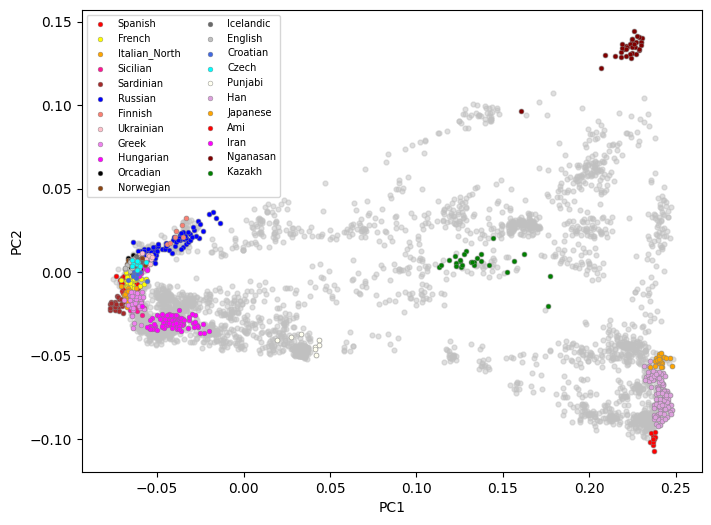

In [93]:
ls=["Spanish", "French", "Italian_North", "Sicilian", "Sardinian", 
    "Russian", "Finnish", "Ukrainian", "Greek", "Hungarian", 
    "Orcadian", "Norwegian", "Icelandic", "English", "Croatian", "Czech", "Punjabi", 
    "Han", "Japanese", "Ami", "Iran", "Nganasan", "Kazakh"]

cs=["red", "yellow", "orange", "deeppink", "brown", "blue", "salmon", 
    "pink", "violet", "magenta", "black", "saddlebrown", 
    "dimgray", "silver", "royalblue", "aqua", "ivory", "plum", "orange", "red", "fuchsia", "maroon", "green"]


plt.figure(figsize=(8,6))
ax = plt.gca()

ax.scatter(-df_pca_ho1["pc1"], df_pca_ho1["pc2"], c="silver", s=12, alpha=0.5)

for l,c in zip(ls,cs):
    dft= df_pca_ho1[df_pca_ho1["pop"].str.contains(l)]
    ax.scatter(-dft["pc1"], dft["pc2"], c=c, s=12, label=l,
               edgecolor="gray", lw=0.3)

ax.legend(loc="upper left", fontsize=7, ncol=2)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()

### 3d) Set colors in HO Projection

In [98]:
df_pca_ho_c = df_pca_ho1.copy()
df_pca_ho_c["c"]="silver"

for l,c in zip(ls,cs):
    idx = df_pca_ho_c["pop"].str.contains(l)
    df_pca_ho_c.loc[idx,"c"]=c
#df_pca_ho_c["pc1"] = - df_pca_ho_c["pc1"] # To account for west/east flip in PC1 above

In [100]:
df_pca_ho_c.to_csv("/mnt/archgen/users/hringbauer/git/projectPCA/projectPCA/data/eurasian_v1/eurasian_ho_proj.c.maf05.tsv", sep="\t")

# 4) Med: West Eurasian - North Africa PCA
PCA based on West Eurasian and North African HO populations. Appears in Ringbauer et al 2025 Punic paper, inspired by earlier work of Inigo Olalde

Based on Harvard Server run - with extracted weights ported to Leipzig server: 
`/mnt/archgen/users/hringbauer/git/projectPCA/input/20230602.punic.v54.1_HO2.construct_WE_NA_PCA.smYES.outitY.weights.txt`

In [27]:
df_w5 = prep_weight_file(path_weights="/mnt/archgen/users/hringbauer/git/projectPCA/input/20230602.punic.v54.1_HO2.construct_WE_NA_PCA.smYES.outitY.weights.txt", 
                         path_snp1240 =  "/mnt/archgen/users/hringbauer/data/afs/v51.1_1240k.snp",
                         path_af="/mnt/archgen/users/hringbauer/data/afs/v51.1_1240k_AF_ch", pcs = 4)

Loaded 532069 SNP weights
Found 532069 / 1233013 1240k SNPs
Filtered to 1090451/1094857 unique AFs
Found and merged in to 520363/532069 Allele Frequencies.


In [28]:
### [Optional Flip of Weights] To account for - signs by chance
df_w5["w2"] = - df_w5["w2"]  # To account for PC1 flip of West / East

In [29]:
df_w5.to_csv("/mnt/archgen/users/hringbauer/git/projectPCA/projectPCA/data/med_v1/med_weights_p.tsv", 
             sep="\t", index=False)

### 4b) Project and save West Eurasian HO individuals
Note that this is not the full Eurasian HO set. Here only relevant West Eurasian populations are projected

In [ ]:
%%time
dfw = pd.read_csv("/mnt/archgen/users/hringbauer/git/projectPCA/projectPCA/data/med_v1/med_weights_p.tsv", sep="\t")
es = get_eigenstrat_object(base_path="/mnt/archgen/users/xiaowen/public_data/HO/HO_WEA_4yilei", mode="unpacked_fast") # Eurasian Dataset
df_pca_ho1 = project_es_obj(es=es, dfw=dfw, verbose=True, maf=0.05, min_snps=100000)

### Add pop labels

In [31]:
### Add IID and POP info from ind file
assert(np.all(df_pca_ho1["iid"]==es.df_ind["iid"]))
df_pca_ho1["iid"]= es.df_ind["iid"]
df_pca_ho1["pop"]= es.df_ind["cls"]

### Save HO Projections

In [32]:
df_pca_ho1.to_csv("/mnt/archgen/users/hringbauer/git/projectPCA/projectPCA/data/med_v1/med_ho_proj.maf05.tsv", sep="\t")

### 4c) Test Plot of PCA projections for verification

In [33]:
df_pca_ho1 = pd.read_csv("/mnt/archgen/users/hringbauer/git/projectPCA/projectPCA/data/med_v1/med_ho_proj.maf05.tsv", 
                         sep="\t")
print(f"Loaded {len(df_pca_ho1)} HO PC projections from MED path.")

Loaded 1300 HO PC projections from MED path.


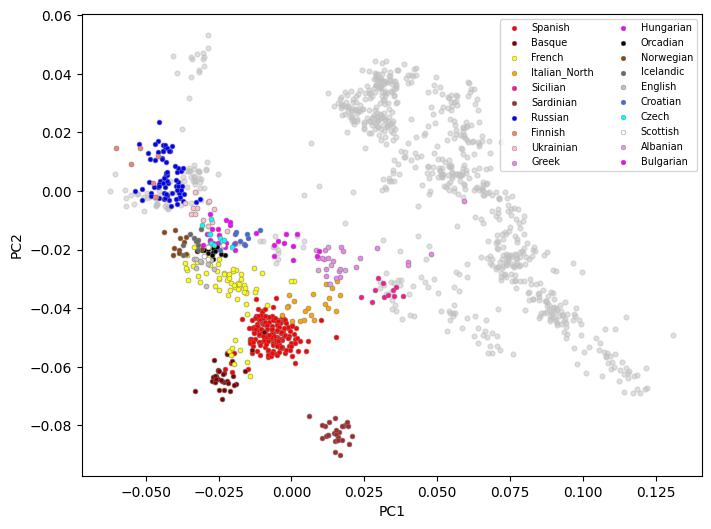

In [36]:
ls=["Spanish", "Basque", "French", "Italian_North", "Sicilian", "Sardinian", 
    "Russian", "Finnish", "Ukrainian", "Greek", "Hungarian", 
    "Orcadian", "Norwegian", "Icelandic", "English", "Croatian", "Czech", "Scottish", 
    "Albanian", "Bulgarian"]

cs=["red", "maroon", "yellow", "orange", "deeppink", "brown", "blue", "salmon", 
    "pink", "violet", "magenta", "black", "saddlebrown", 
    "dimgray", "silver", "royalblue", "aqua", "ivory", "plum", "fuchsia"]

plt.figure(figsize=(8,6))
ax = plt.gca()

ax.scatter(df_pca_ho1["pc1"], df_pca_ho1["pc2"], c="silver", s=12, alpha=0.5)

for l,c in zip(ls,cs):
    dft= df_pca_ho1[df_pca_ho1["pop"].str.contains(l)]
    ax.scatter(dft["pc1"], dft["pc2"], c=c, s=12, label=l,
               edgecolor="gray", lw=0.3)

ax.legend(loc="upper right", fontsize=7, ncol=2)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()

# Area 51

In [87]:
dft =  pd.read_csv("/mnt/archgen/users/xiaowen/public_data/HO/HO_1123.ind", sep=r"\s+", header=None, skiprows=0)
dft.columns = ["iid", "sex", "clst"]

In [ ]:
dft[dft["clst"].str.contains("Kaz")]

In [42]:
dft[2].value_counts()[:50]

2
Spanish.HO                172
Han.HO                    107
Tibetan.HO                 97
Russian.HO                 71
French.HO                  61
Bashkir.HO                 53
Turkish.HO                 50
YRI.HO                     48
Druze.HO                   39
Iranian.HO                 38
Buryat.HO                  37
Mongol.HO                  34
Palestinian.HO             34
Nganasan.HO                33
Mordovian.HO               32
Adygei.HO                  31
Tajik.HO                   31
Akha.HO                    30
Basque.HO                  29
Japanese.HO                29
Yemeni_Highlands.HO        29
Yemeni_Northwest.HO        28
Uzbek.HO                   27
Tubalar.HO                 27
Ignore_YRI_relative.HO     27
Sardinian.HO               25
Ulchi.HO                   25
BedouinA.HO                25
Iran_Zoroastrian.HO        24
Selkup.HO                  24
Altaian.HO                 24
Burusho.HO                 23
Georgian.HO                23
Mozabite